In [3]:
from Configurations.imports import *
from Configurations.file_path import data_parent_path

In [5]:
file_path = data_parent_path / "Algerian_forest_fires_dataset_UPDATE.csv"

In [108]:
df = pd.read_csv(file_path, delimiter=",")
df.head()

,,,,,,,,,,,,,Bejaia Region Dataset
day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire


In [109]:
# get all the lines
with open(file_path, "r") as f:
    lines = f.readlines()
    
split_index = -1

for i,line in enumerate(lines):
    if "Sidi-Bel Abbes" in line:
        split_index = i
        break
    
data1 = lines[1:split_index]
data2 = lines[split_index + 1:]


In [110]:
# file can not just make data frame reading the list of strings
# first make it behave like a csv and then create a fake file pretending to be a file

from io import StringIO

df1 = pd.read_csv(StringIO("".join(data1)))
df2 = pd.read_csv(StringIO("".join(data2)))

df1.head()
df2.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire
1,2,6,2012,30,73,13,4.0,55.7,2.7,7.8,0.6,2.9,0.2,not fire
2,3,6,2012,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0.1,not fire
3,4,6,2012,30,64,14,0.0,79.4,5.2,15.4,2.2,5.6,1,not fire
4,5,6,2012,32,60,14,0.2,77.1,6.0,17.6,1.8,6.5,0.9,not fire


In [111]:
# Cleaning the dataset df1

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          122 non-null    int64  
 1   month        122 non-null    int64  
 2   year         122 non-null    int64  
 3   Temperature  122 non-null    int64  
 4    RH          122 non-null    int64  
 5    Ws          122 non-null    int64  
 6   Rain         122 non-null    float64
 7   FFMC         122 non-null    float64
 8   DMC          122 non-null    float64
 9   DC           122 non-null    float64
 10  ISI          122 non-null    float64
 11  BUI          122 non-null    float64
 12  FWI          122 non-null    float64
 13  Classes      122 non-null    object 
dtypes: float64(7), int64(6), object(1)
memory usage: 13.5+ KB


In [112]:
# standardize the columns
df1.columns = df1.columns.str.strip().str.lower().str.replace(" " , "_")
df2.columns = df1.columns.str.strip().str.lower().str.replace(" " , "_")

In [113]:
# Handle the null values
df1.isna().sum()

day            0
month          0
year           0
temperature    0
rh             0
ws             0
rain           0
ffmc           0
dmc            0
dc             0
isi            0
bui            0
fwi            0
classes        0
dtype: int64

In [114]:
df2.isna().sum()
df2["classes"] = df2["classes"].ffill()


In [115]:
# combine both data frames
df1["region"] = 1
df2["region"] = 0

df = pd.concat([df1,df2]).reset_index()
df.drop("index",axis=1, inplace=True)

In [116]:
# check for the duplicates
df.duplicated().sum()

np.int64(0)

In [117]:
# checking the data types of the columns
df.info()
# there is problem with the dc, fwi

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    int64  
 1   month        244 non-null    int64  
 2   year         244 non-null    int64  
 3   temperature  244 non-null    int64  
 4   rh           244 non-null    int64  
 5   ws           244 non-null    int64  
 6   rain         244 non-null    float64
 7   ffmc         244 non-null    float64
 8   dmc          244 non-null    float64
 9   dc           244 non-null    object 
 10  isi          244 non-null    float64
 11  bui          244 non-null    float64
 12  fwi          244 non-null    object 
 13  classes      244 non-null    object 
 14  region       244 non-null    int64  
dtypes: float64(5), int64(7), object(3)
memory usage: 28.7+ KB


In [118]:
df["dc"] = pd.to_numeric(df["dc"], errors="coerce")
df["fwi"] = pd.to_numeric(df["fwi"], errors="coerce")

df.isna().sum()
#drop the null rows
df.dropna(inplace=True)

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   temperature  243 non-null    int64  
 4   rh           243 non-null    int64  
 5   ws           243 non-null    int64  
 6   rain         243 non-null    float64
 7   ffmc         243 non-null    float64
 8   dmc          243 non-null    float64
 9   dc           243 non-null    float64
 10  isi          243 non-null    float64
 11  bui          243 non-null    float64
 12  fwi          243 non-null    float64
 13  classes      243 non-null    object 
 14  region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 30.4+ KB


In [120]:
# handling the classes column
df["classes"] = df["classes"].str.strip().str.lower().str.replace(" ","_")

In [121]:
# Storing the cleaned dataset
df.to_csv(data_parent_path/"cleaned_dataset.csv", index=False)

#### Exploratory Data Analysis

In [122]:
# Dropping the unnecessary columns
df_copy = df.drop(["day","month","year"], axis=1)
df_copy.head()

,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not_fire,1
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not_fire,1
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not_fire,1
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not_fire,1
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not_fire,1


In [ ]:
# encoding the classes
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

encoded_data = encoder.fit_transform(df[["classes"]])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(["classes"])
)

In [125]:
# joining the dataset
df_copy.drop("classes",axis=1,inplace=True)

In [128]:
df_copy = pd.concat([df_copy, encoded_df], axis=1)
df_copy

,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,region,classes_fire,classes_not_fire,classes_fire,classes_not_fire
0,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,1.0,0.0,1.0,0.0,1.0
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,1.0,0.0,1.0,0.0,1.0
2,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,1.0,0.0,1.0,0.0,1.0
3,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,1.0,0.0,1.0,0.0,1.0
4,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,1.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,28.0,87.0,15.0,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0.0,0.0,1.0,0.0,1.0
241,27.0,87.0,29.0,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0.0,0.0,1.0,0.0,1.0
242,24.0,54.0,18.0,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0.0,0.0,1.0,0.0,1.0
243,24.0,64.0,15.0,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0.0,NaN,NaN,NaN,NaN


In [136]:
# drop the duplicate columns
df_copy = df_copy.T.drop_duplicates().T
df_copy

,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,region,classes_fire,classes_not_fire
0,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,1.0,0.0,1.0
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,1.0,0.0,1.0
2,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,1.0,0.0,1.0
3,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,1.0,0.0,1.0
4,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,28.0,87.0,15.0,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0.0,0.0,1.0
241,27.0,87.0,29.0,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0.0,0.0,1.0
242,24.0,54.0,18.0,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0.0,0.0,1.0
243,24.0,64.0,15.0,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0.0,NaN,NaN


In [147]:
df_copy = df_copy.dropna()
df_copy

,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,region,classes_fire,classes_not_fire
0,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,1.0,0.0,1.0
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,1.0,0.0,1.0
2,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,1.0,0.0,1.0
3,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,1.0,0.0,1.0
4,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,28.0,70.0,15.0,0.0,79.9,13.8,36.1,2.4,14.1,3.0,0.0,1.0,0.0
239,30.0,65.0,14.0,0.0,85.4,16.0,44.5,4.5,16.9,6.5,0.0,0.0,1.0
240,28.0,87.0,15.0,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0.0,0.0,1.0
241,27.0,87.0,29.0,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0.0,0.0,1.0


In [153]:
# another approach to remove the duplicate columns
df_copy.loc[:, ~df_copy.columns.duplicated()]

,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,region,classes_fire,classes_not_fire
0,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,1.0,0.0,1.0
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,1.0,0.0,1.0
2,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,1.0,0.0,1.0
3,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,1.0,0.0,1.0
4,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,28.0,70.0,15.0,0.0,79.9,13.8,36.1,2.4,14.1,3.0,0.0,1.0,0.0
239,30.0,65.0,14.0,0.0,85.4,16.0,44.5,4.5,16.9,6.5,0.0,0.0,1.0
240,28.0,87.0,15.0,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0.0,0.0,1.0
241,27.0,87.0,29.0,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0.0,0.0,1.0


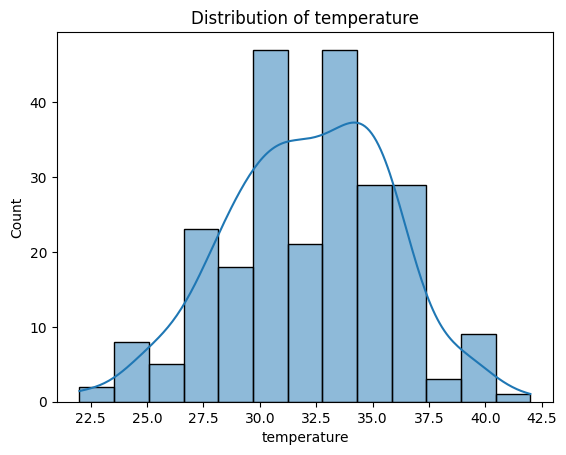

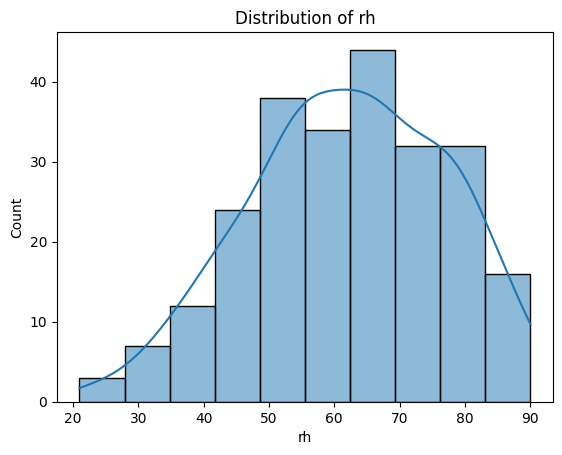

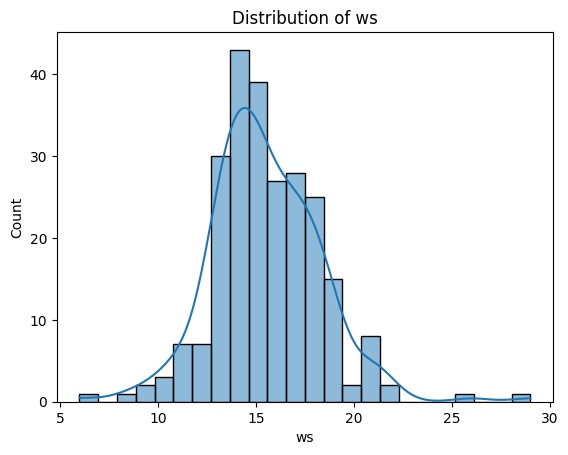

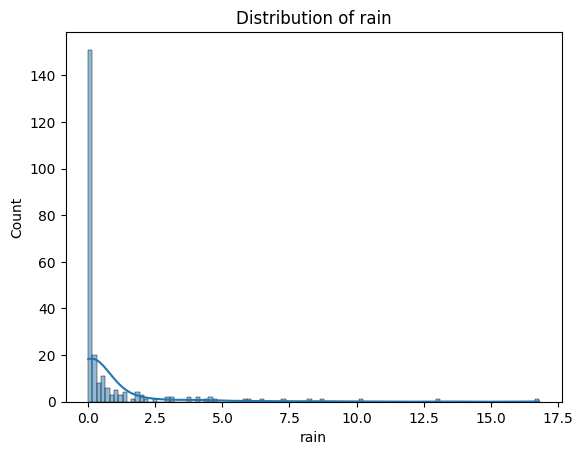

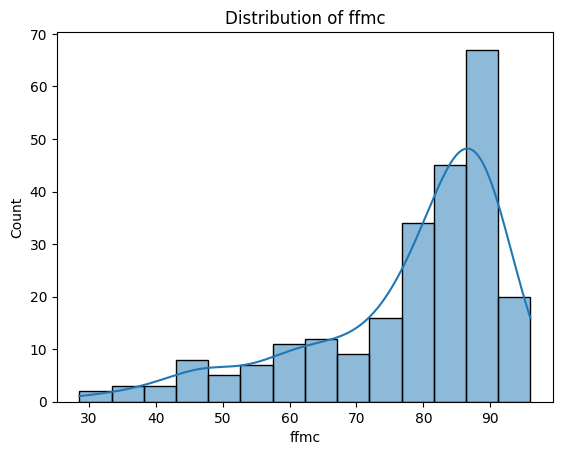

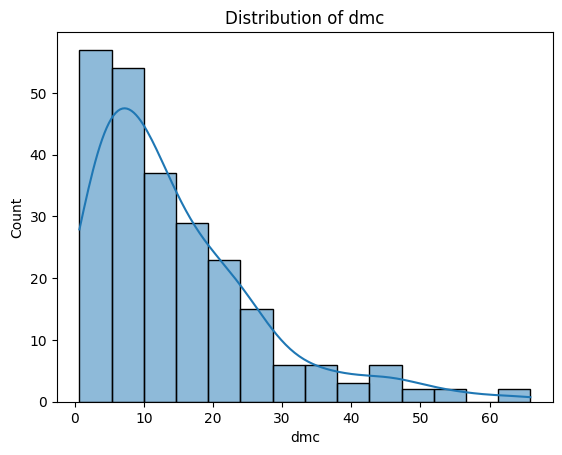

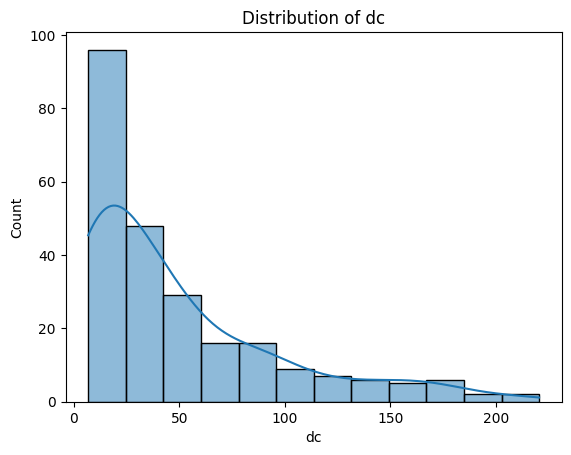

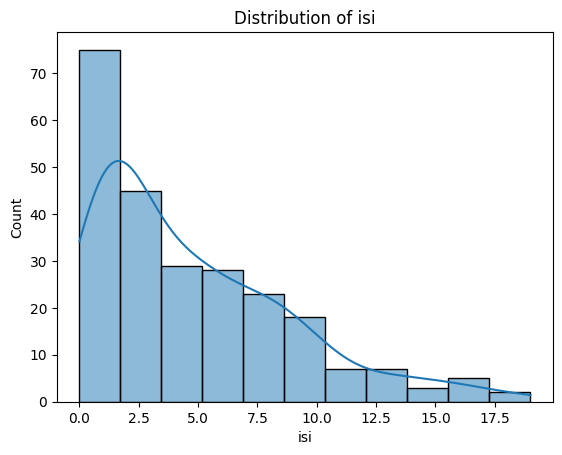

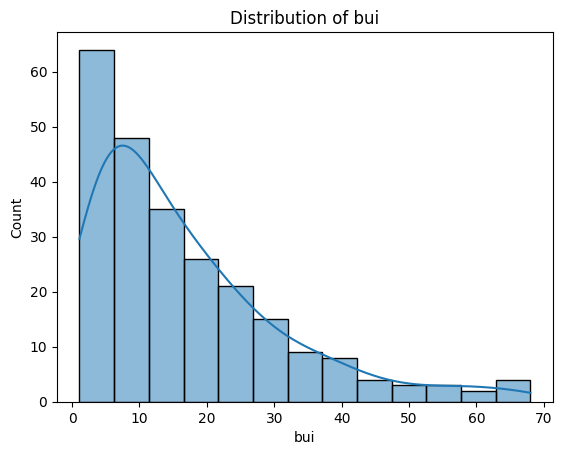

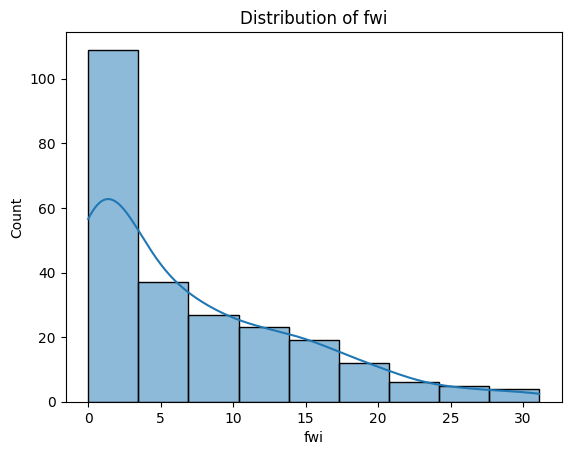

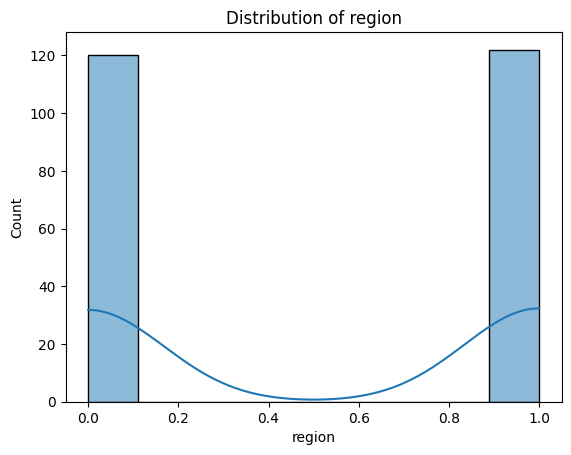

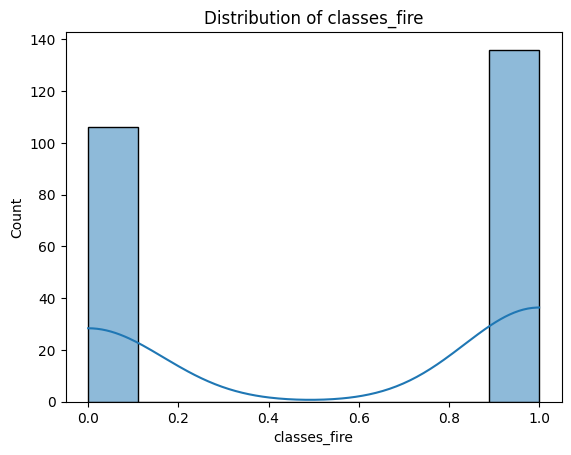

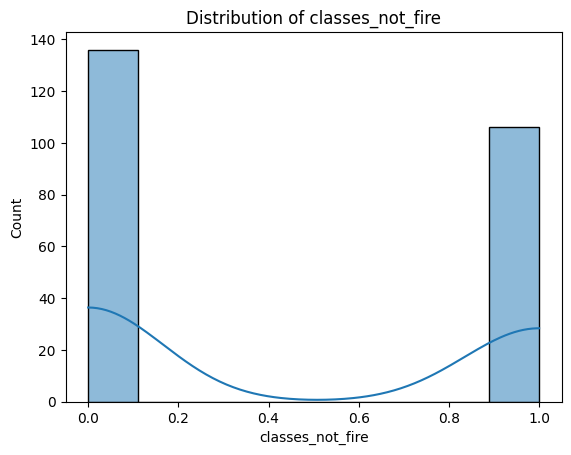

In [159]:
# checking the distribution of all numerical features

num_cols = df_copy.select_dtypes(include=["number"])

for col in num_cols.columns:
    plt.figure()
    sns.histplot(num_cols[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

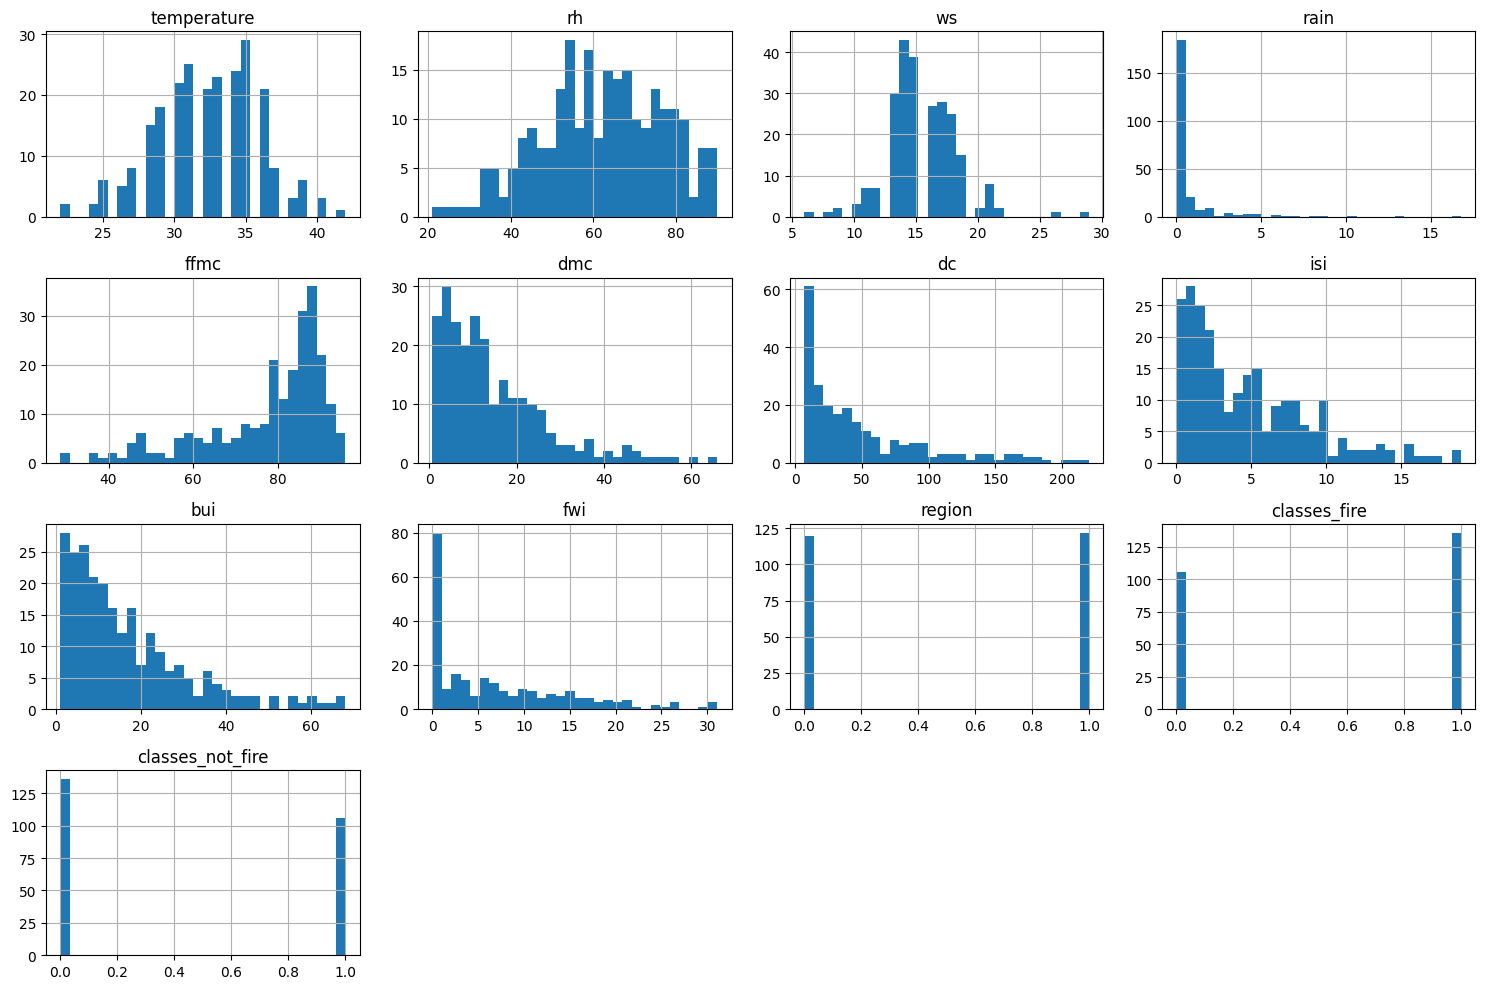

In [162]:
num_cols.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

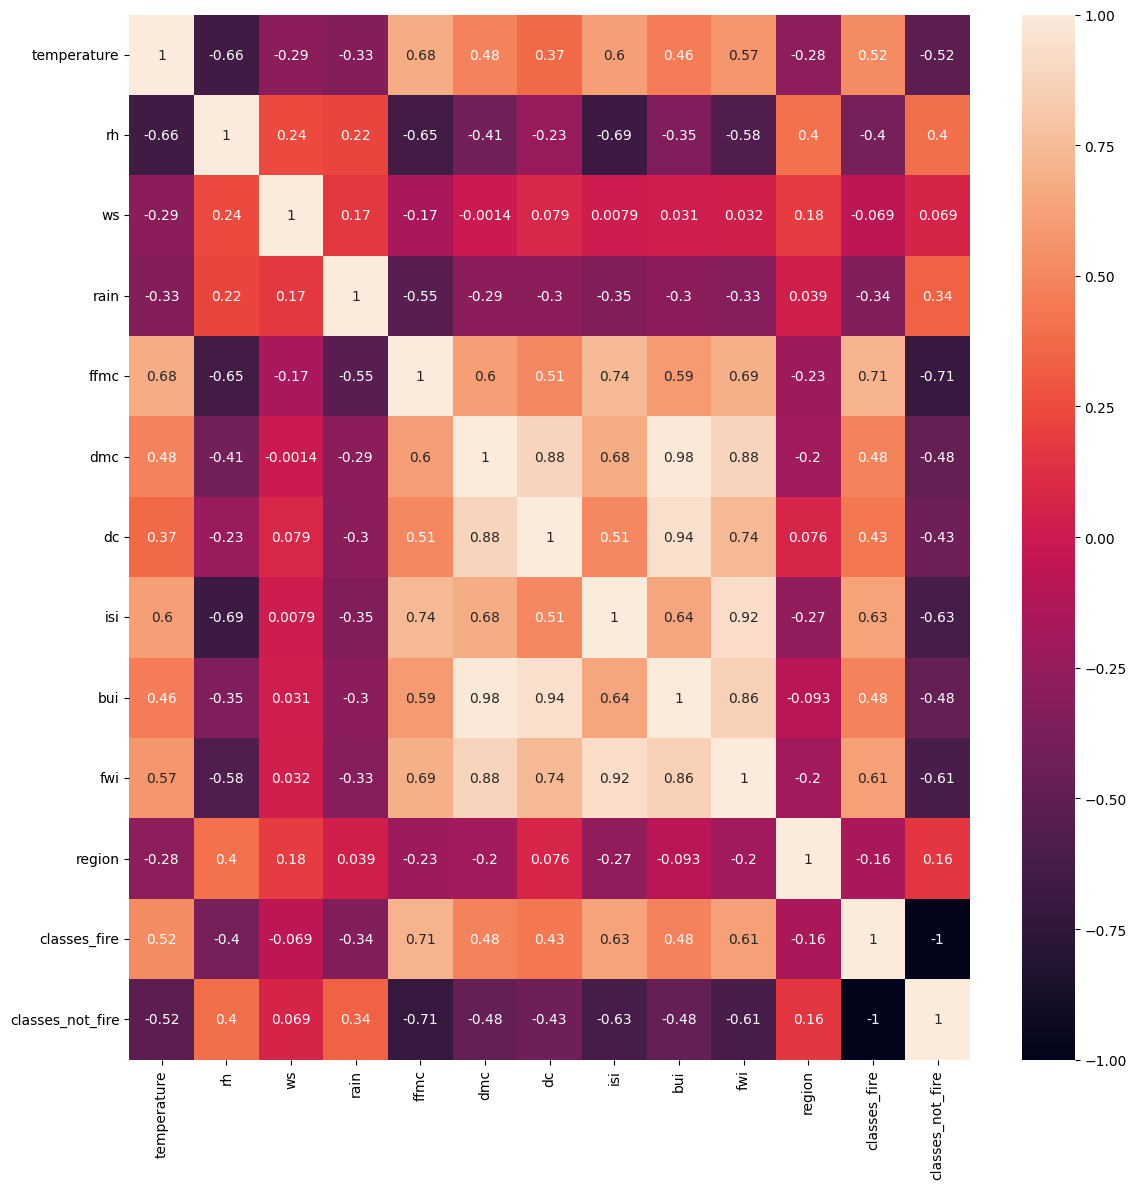

In [172]:
# Checking the correlation
plt.figure(figsize=(12, 12)) 
sns.heatmap(df_copy.corr(), annot=True)
plt.tight_layout()
plt.show()

In [182]:
# correlation analysis
# getting what are the features which are actually affecting the fire 
df_copy.corr()["classes_fire"].sort_values(ascending=False)

classes_fire        1.000000
ffmc                0.707102
isi                 0.626957
fwi                 0.610376
temperature         0.516707
dmc                 0.479410
bui                 0.478758
dc                  0.432435
ws                 -0.069439
region             -0.159283
rain               -0.337158
rh                 -0.397964
classes_not_fire   -1.000000
Name: classes_fire, dtype: float64

In [174]:
# checking the balance of the fire and not fire class
df_copy["classes_fire"].value_counts()

classes_fire
1.0    136
0.0    106
Name: count, dtype: int64

<Axes: xlabel='region', ylabel='count'>

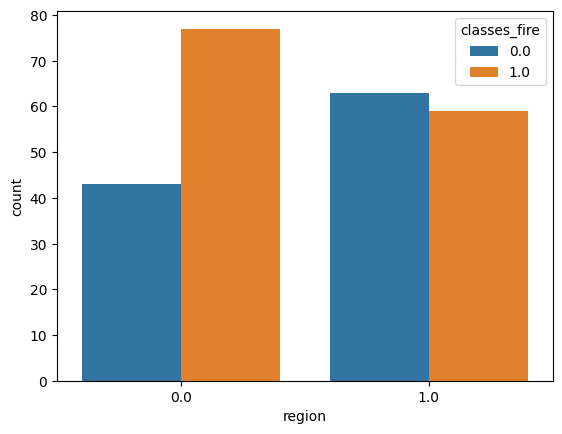

In [ ]:
# region wise 
sns.countplot(x="region", hue="classes_fire", data=df_copy)

# EDA Observations

## 1. Target Distribution
- Fire (1): 136  
- Not Fire (0): 106  

- Dataset is slightly imbalanced but acceptable  
- No immediate need for resampling  

---

## 2. Correlation with Target (classes_fire)

### Strong Positive Correlation
- FFMC (0.70) → strongest indicator  
- ISI (0.62)  
- FWI (0.61)  

- These indices are highly related to fire occurrence  

---

### Moderate Positive Correlation
- Temperature (0.51)  
- DMC (0.47)  
- BUI (0.47)  
- DC (0.43)  

- Higher temperature and dryness increase fire probability  

---

### Negative Correlation
- RH (-0.39) → higher humidity reduces fire  
- Rain (-0.33) → rainfall suppresses fire  
- Region (-0.15) → weak influence  

---

### Strong Negative
- classes_not_fire (-1.00)  
- Perfect inverse of target → redundant feature  

---

## 3. Region-wise Analysis
- Region 0 has more fire cases than non-fire  
- Region 1 has slightly more non-fire cases  

- Region has some influence but not very strong  

---

## 4. Key Insights
- Fire occurrence is strongly driven by weather indices (FFMC, ISI, FWI)  
- Temperature and dryness increase fire risk  
- Rain and humidity reduce fire probability  
- Some features are highly correlated → possible multicollinearity  

---
